## Parameterised tests
Let's remind ourselves of our Inventory application.

The `add_new_stock()` needs to validate input - raise an exception if the quantity is zero or negative, or if it carries us over our inventory's limit.

**How can this be achieved?**

Two possibilities:
- add more test cases
- use try/except to catch each exception

Both of these are repetitive.

**A better way**

- Pytest's  parametrized functions allow testing of multiple scenarios using one function. 

We now write a parametrized test function to ensure our input validation works:

In [ ]:
## add this to your test module

@pytest.mark.parametrize('name,price,quantity,exception', [
    ('Test Jacket', 10.00, 0, InvalidQuantityException(
        'Cannot add a quantity of 0. All new stocks must have at least 1 item'))
])
def test_add_new_stock_bad_input(name, price, quantity, exception):
    inventory = Inventory(10)
    try:
        inventory.add_new_stock(name, price, quantity)
    except InvalidQuantityException as inst:
        # First ensure the exception is of the right type
        assert isinstance(inst, type(exception))
        # Ensure that exceptions have the same message
        assert inst.args == exception.args
    else:
        pytest.fail("Expected error but found none")

### Discussion

The test tries to add a stock, gets the exception and then checks that it's the right exception. If we don't get an exception, fail the test. The else clause is very important in this scenario. Without it, an exception that wasn't thrown would count as a pass. Our test would therefore have a false positive.

We use pytest decorators to add a parameter to the function. The first argument contains a string of all the parameter names. The second argument is a list of tuples where each tuple is a test case.

Run `pytest` - test fails because `InvalidQuantityException` is not defined. 

In the `inventory.py` create a new exception above the Inventory class:

In [ ]:
class InvalidQuantityException(Exception):
    pass


Modify the the `add_new_stock()` method:

In [ ]:
    def add_new_stock(self, name, price, quantity):
        if quantity <= 0:
            raise InvalidQuantityException(
                'Cannot add a quantity of {}. All new stocks must have at least 1 item'.format(quantity))
        self.stocks[name] = {
            'price': price,
            'quantity': quantity
        }
        self.total_items += quantity

Run `pytest` - the most recent test now passes. 

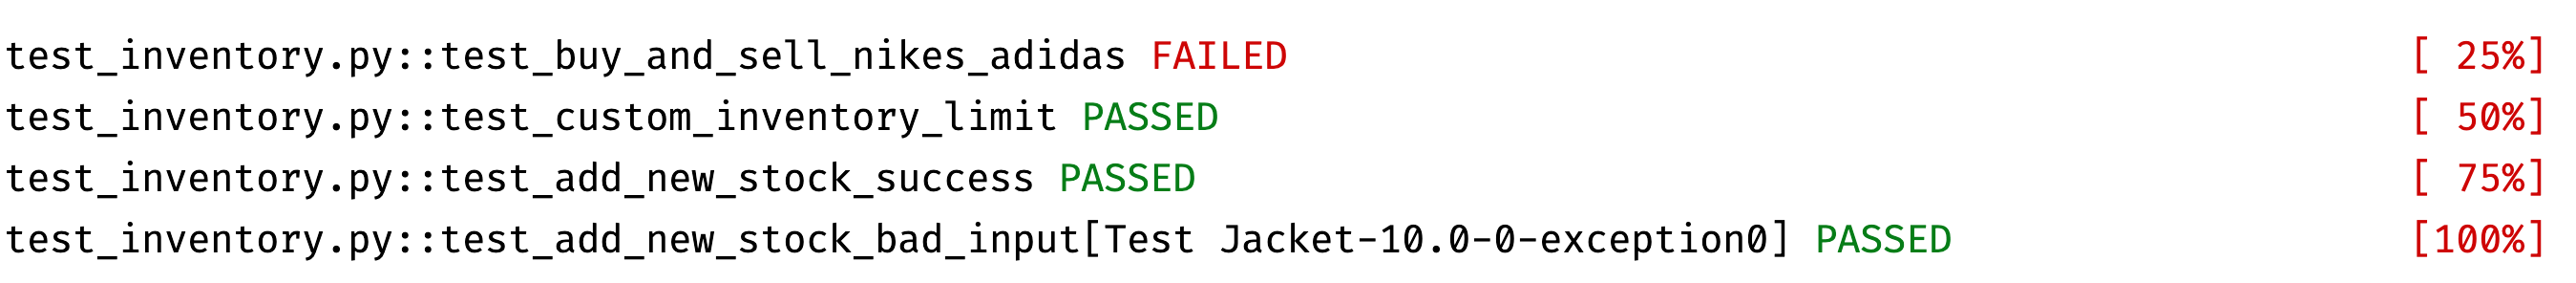

We now add the second error test case - an exception is raised if our inventory can't store it. Change the test as follows:



In [ ]:
@pytest.mark.parametrize('name,price,quantity,exception', [
    ('Test Jacket', 10.00, 0, InvalidQuantityException(
        'Cannot add a quantity of 0. All new stocks must have at least 1 item')),
    ('Test Jacket', 10.00, 25, NoSpaceException(
        'Cannot add these 25 items. Only 10 more items can be stored'))
])
def test_add_new_stock_bad_input(name, price, quantity, exception):
    inventory = Inventory(10)
    try:
        inventory.add_new_stock(name, price, quantity)
    except (InvalidQuantityException, NoSpaceException) as inst:
        # First ensure the exception is of the right type
        assert isinstance(inst, type(exception))
        # Ensure that exceptions have the same message
        assert inst.args == exception.args
    else:
        pytest.fail("Expected error but found none")

#### Thoughts
We modify the test function slightly to pick up our new exception and add another tuple to the decorator! Now two tests are executed on a single function.

Parametrized functions cut down on the time it takes to add new test cases.

In `inventory.py`, we  add our new exception `NoSpaceException` below `InvalidQuantityException`:

In [ ]:
class NoSpaceException(Exception):
    pass

In [ ]:
# change the add_new_stock() function

def add_new_stock(self, name, price, quantity):
    if quantity <= 0:
        raise InvalidQuantityException(
            'Cannot add a quantity of {}. All new stocks must have at least 1 item'.format(quantity))
    if self.total_items + quantity > self.limit:
        remaining_space = self.limit - self.total_items
        raise NoSpaceException(
            'Cannot add these {} items. Only {} more items can be stored'.format(quantity, remaining_space))
    self.stocks[name] = {
        'price': price,
        'quantity': quantity
    }
    self.total_items += quantity

Run `pytest` - new test case passes.

Use `fixtures` with the parametrized function.

**Refactor** the test to use the empty inventory fixture:

In [ ]:
def test_add_new_stock_bad_input(no_stock_inventory, name, price, quantity, exception):
    try:
        no_stock_inventory.add_new_stock(name, price, quantity)
    except (InvalidQuantityException, NoSpaceException) as inst:
        # First ensure the exception is of the right type
        assert isinstance(inst, type(exception))
        # Ensure that exceptions have the same message
        assert inst.args == exception.args
    else:
        pytest.fail("Expected error but found none")

#### Reflections
- Use of fixture -  just another argument that uses the name of a function; ensureto exclude it in the parametrize decorator.

**Note** - there's no reason why there needs to be two methods to for adding new stocks. We can test errors and success in one function.

Let's delete `test_add_new_stock_bad_input()` and `test_add_new_stock_success()`. Then add a new function:


In [ ]:
@pytest.mark.parametrize('name,price,quantity,exception', [
    ('Test Jacket', 10.00, 0, InvalidQuantityException(
        'Cannot add a quantity of 0. All new stocks must have at least 1 item')),
    ('Test Jacket', 10.00, 25, NoSpaceException(
        'Cannot add these 25 items. Only 10 more items can be stored')),
    ('Test Jacket', 10.00, 5, None)
])
def test_add_new_stock(no_stock_inventory, name, price, quantity, exception):
    try:
        no_stock_inventory.add_new_stock(name, price, quantity)
    except (InvalidQuantityException, NoSpaceException) as inst:
        # First ensure the exception is of the right type
        assert isinstance(inst, type(exception))
        # Ensure that exceptions have the same message
        assert inst.args == exception.args
    else:
        assert no_stock_inventory.total_items == quantity
        assert no_stock_inventory.stocks[name]['price'] == price
        assert no_stock_inventory.stocks[name]['quantity'] == quantity

### What we have just done
Make one test function check for known exceptions, if none are found then we ensure the addition matches our expectations. The separate `test_add_new_stock_success()` function is now just executed via a tupled parameter. As we don't expect an exception to be thrown in the successful case, we specify None as our exception.


#### Finally - almost there

Let's turn our attention to the `remove_stock` function. In `test_inventory.py` add:

In [ ]:
# The import statement needs one more exception
from inventory import Inventory, InvalidQuantityException, NoSpaceException, ItemNotFoundException

# ...
# Add a new fixture that contains stocks by default
# This makes writing tests easier for our remove function
@pytest.fixture
def ten_stock_inventory():
    """Returns an inventory with some test stock items"""
    inventory = Inventory(20)
    inventory.add_new_stock('Puma Test', 100.00, 8)
    inventory.add_new_stock('Reebok Test', 25.50, 2)
    return inventory


# Note the extra parameters, we need to set our expectation of
# what totals should be after our remove action
@pytest.mark.parametrize('name,quantity,exception,new_quantity,new_total', [
    ('Puma Test', 0,
     InvalidQuantityException(
         'Cannot remove a quantity of 0. Must remove at least 1 item'),
        0, 0),
    ('Not Here', 5,
     ItemNotFoundException(
         'Could not find Not Here in our stocks. Cannot remove non-existing stock'),
        0, 0),
    ('Puma Test', 25,
     InvalidQuantityException(
         'Cannot remove these 25 items. Only 8 items are in stock'),
     0, 0),
    ('Puma Test', 5, None, 3, 5)
])
def test_remove_stock(ten_stock_inventory, name, quantity, exception,
                      new_quantity, new_total):
    try:
        ten_stock_inventory.remove_stock(name, quantity)
    except (InvalidQuantityException, NoSpaceException, ItemNotFoundException) as inst:
        assert isinstance(inst, type(exception))
        assert inst.args == exception.args
    else:
        assert ten_stock_inventory.stocks[name]['quantity'] == new_quantity
        assert ten_stock_inventory.total_items == new_total

In the `inventory.py` module,  create the new exception for when users try to modify a stock that doesn't exist:


In [ ]:
class ItemNotFoundException(Exception):
    pass

Now,  add this method to our Inventory class:

In [ ]:
def remove_stock(self, name, quantity):
    if quantity <= 0:
        raise InvalidQuantityException(
            'Cannot remove a quantity of {}. Must remove at least 1 item'.format(quantity))
    if name not in self.stocks:
        raise ItemNotFoundException(
            'Could not find {} in our stocks. Cannot remove non-existing stock'.format(name))
    if self.stocks[name]['quantity'] - quantity <= 0:
        raise InvalidQuantityException(
            'Cannot remove these {} items. Only {} items are in stock'.format(
                quantity, self.stocks[name]['quantity']))
    self.stocks[name]['quantity'] -= quantity
    self.total_items -= quantity

**Finally now** <br>
Run `pytest -v test_inventory.py`  - the integration test and all others pass!

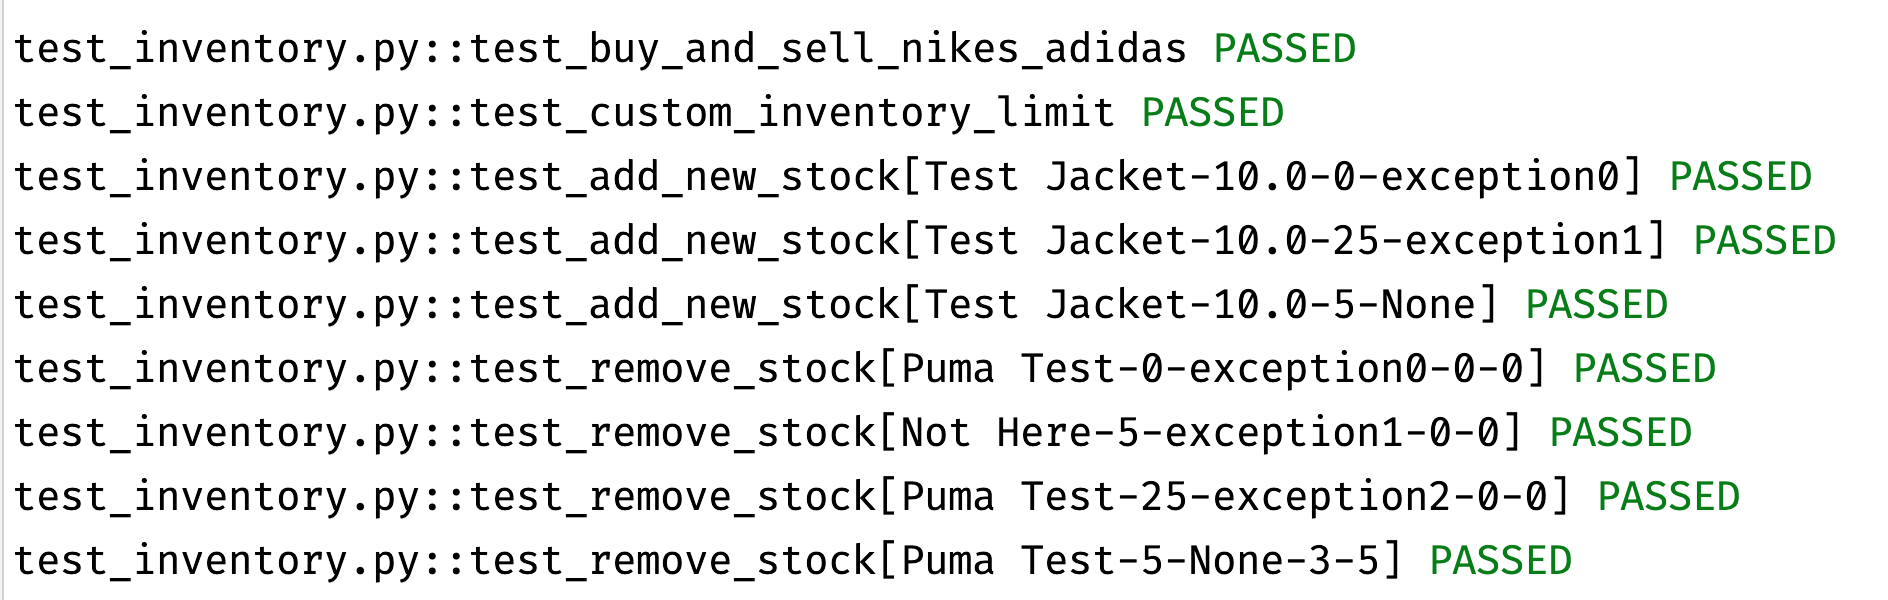


### Task 1

Go over this part again ...twice or thrice. It does represent typical approach to unit testing and integration testing.

### Task 2
In this task, we will learn how to test features that are encapsulated in a class. That is, you create a Python module, and in it a class. The class has methods that you will test. Let's do it.
1. Create a Python module called `main_calc.py`
2. In `main_calc.py` create a calss called `SimpleCalculator`.
3. Leave the class unimplemented.

**Now, turn to your test module**

4. Create a module called `test_main_calc.py`.
5. Write the test below in it:

In [ ]:
def test_div_two_numbers_float(): 
    calc = SimpleCalculator()

    result = calc.divide(13, 2)

    assert result == 6.5

**run your test and obseve the outcome**

What do you have to do to get the test to pass?

6. implement the `divide` method in SimpleCalculator` class and run the test again`

Try this value in your test method `a = 15, b = 0`

The test will fail with a `ZeroDvision` exception.

Fix your `div` method to handle this case. Use an exception handler or any other creative way.

7. Create the test cases below in `test_main_calc.py`

In [ ]:

def test_add_two_numbers():
    calculator = SimpleCalculator()

    result = calculator.addition(4, 5)

    assert result == 9


def test_add_three_numbers():
    calculator = SimpleCalculator()

    result = calculator.addition(4, 5, 6)

    assert result == 15


def test_add_many_numbers():
    numbers = range(100)

    calculator = SimpleCalculator()

    result = calculator.addition(*numbers)

    assert result == 4950


def test_subtract_two_numbers():
    calc = SimpleCalculator()

    result = calc.subtract(10, 3)

    assert result == 7


def test_mul_two_numbers():
    calculator = SimpleCalculator()

    result = calculator.multiply(6, 4)

    assert result == 24


def test_multiply_many_numbers():
    numbers = range(1, 10)

    calc = SimpleCalculator()

    result = calc.multiply(*numbers)

    assert result == 362880


def test_div_two_numbers_float():
    calc = SimpleCalculator()

    result = calc.divide(13, 2)

    assert result == 6.5


def test_div_by_zero_returns_inf():
    calc = SimpleCalculator()

    result = calc.divide(5, 0)

    assert result == float('inf')


def test_mul_by_zero_raises_exception():
    calc = SimpleCalculator()

    with pytest.raises(ValueError):
        calc.multiply(3, 0)


**Write the methods one at a time, running the tests to make sure they pass**